<a href="https://colab.research.google.com/github/LeandroLDA/ColabNotebooks/blob/main/Prova_Final_ECD_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prova Final


## Estatística para Ciência de Dados

por **Cibele Russo** (ICMC/USP - São Carlos SP)

**MBA em Ciências de Dados**

O conjunto de dados "Breast Cancer Wisconsin (Diagnostic)" contém características extraídas dos exames de diagnóstico de câncer de mama, obtidas a partir de imagens digitalizadas das células, e a resposta, se o tumor é maligno ou benigno.

Do total de variáveis, foi feita uma seleção inicial, que levou às colunas

- Pontos côncavos médios: mean concave points
- Perímetro médio: mean perimeter
- Dimensão fractal média: mean fractal dimension
- Pior perímetro: worst perimeter
- Pior textura: worst texture
- Pior área: worst area
- Tipo: 1: maligno, 0: benigno (variável resposta).

1. Investigue a associação de cada uma dessas variáveis com o tipo de tumor via **análise exploratória de dados** (sugestão: use boxplots). Comente os resultados obtidos. Construa também uma **matriz de gráficos de dispersão** (sugestão: use pairplot) para verificar a associação entre as preditoras. Comente os resultados obtidos.


2. Por engano, um pesquisador ajustou um **modelo de regressão linear** com a resposta 'worst texture' e todas as outras variáveis como preditoras, incluindo o tipo de tumor. Considerando o valor-p (P>|t|), indique as preditoras com significância estatística marginal neste modelo.


3. Ajuste um **modelo de regressão logística** para o tipo de tumor como resposta, com preditoras 'mean concave points', 'mean perimeter', 'mean fractal dimension', 'worst perimeter', 'worst texture', 'worst area'. Esse modelo é um MLG com resposta binomial e ligação logito.
  * Avalie como as preditoras perímetro médio (mean_perimeter) e pior textura (worst_texture) influenciam na resposta tipo de tumor (sugestão: razão de chances, dada neste modelo por $OR = \exp(b_j)$, em que $b_j$ é o coeficiente estimado correspondente à j-ésima preditora).
  * Desenvolva uma análise de resíduos e, caso haja observações em destaque, identifique-as e descreva as suas características.
  * Explique por que se deve usar um modelo de regressão logística ao invés de um modelo linear nesse caso.

Alguns códigos são fornecidos abaixo para a leitura dos dados e o início da análise. Para este item, considere que não é necessário fazer mais nenhuma seleção de variáveis ou dividir a base em treinamento e teste.

A entrega deve ser feita com um notebook .ipynb, com os códigos usados para a obtenção dos resultados. Este notebook deve ser comentado de forma a facilmente identificar os códigos de cada análise.

Atenção, se constatado plágio, a questão será zerada.

Referência:
Wolberg, W. H., Street, W. N., & Mangasarian, O. L. (1992). Breast Cancer Wisconsin (Diagnostic) Data Set. UCI Machine Learning Repository. Disponível em: https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic)

In [1]:
# Carrega os pacotes
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

# Leitura dos dados
df = pd.read_csv('https://raw.githubusercontent.com/cibelerusso/Estatistica-Ciencia-Dados/main/Data/breast_cancer.csv', index_col=0)
df.head()

,mean_concave_points,mean_perimeter,mean_fractal_dimension,worst_perimeter,worst_texture,worst_area,target
0,0.14710,122.80,0.07871,184.60,17.33,2019.0,1
1,0.07017,132.90,0.05667,158.80,23.41,1956.0,1
2,0.12790,130.00,0.05999,152.50,25.53,1709.0,1
3,0.10520,77.58,0.09744,98.87,26.50,567.7,1
4,0.10430,135.10,0.05883,152.20,16.67,1575.0,1


## 1. Análise exploratória



### <font color = " red">Análise de mean_concave_points

<font color = " red">Essa caracteristica é um preditor promissor, pois os valores positivos do target estão bem separados dos negativos e visivelmente os valores mais altos de **mean_concave_points** implicam em casos positivos da doença. Outra observaçao curiosa é que os outliers de casos negativos são possiveis positivos e os outliers de positivo estão apenas na banda superior dos casos positivos o que também aponta para possíveis casos positivos.

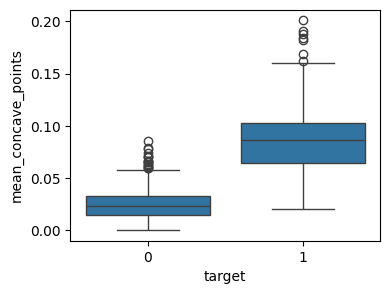

In [2]:
plt.figure(figsize=(4, 3))
sns.boxplot(data=df, x='target', y='mean_concave_points');

### <font color = " red">Análise de mean_perimeter

<font color = " red">Não é um bom indicador como *mean_concave_points* mas separa relativamente bem as classes. Os outliers da classe negativa estão distribuidos nos extremos da classe, proximos dos bigodes. Em casos assim, é bom avaliar cuidadosamente se apesar de outliers, esses dados ainda são relevantes para a análise.

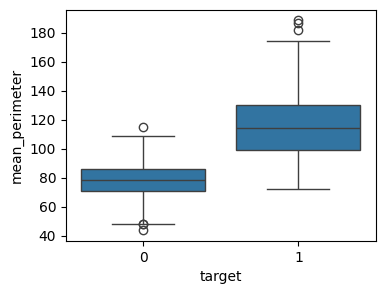

In [3]:
plt.figure(figsize=(4, 3))
sns.boxplot(data=df, x='target', y='mean_perimeter');

### <font color = " red">mean_fractal_dimension

<font color = " red">Claramente não é conclusiva, pois as classes estão no mesmo range de valores. Embora tenham dimenões um pouco diferentes a sua mediana e seus quartis 2 e 3 se confundem, sendo assim facilmente descartada para uma avaliaçao individual. Talvez no uso do pairplot seja possivel inferir algo quando essa variavel for correlacionada com outras preditoras.

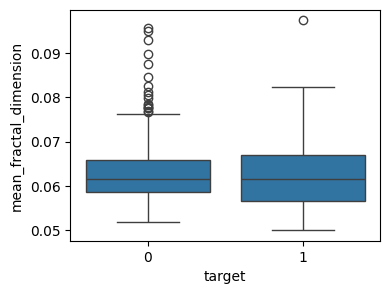

In [4]:
plt.figure(figsize=(4, 3))
sns.boxplot(data=df, x='target', y='mean_fractal_dimension');

### <font color = " red">worst_perimeter
<font color = " red">Variavel com capacidade de inferência semelhante a *mean_concave_points* com medianas quartis 2 e 3 bem separados e o bigode superior de casos negativos quase não alcança o quartil 2 da classe positiva

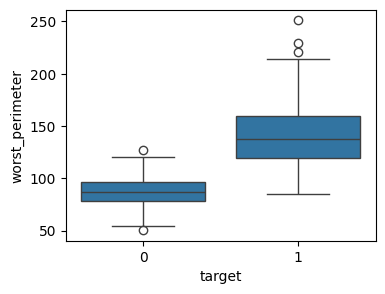

In [5]:
plt.figure(figsize=(4, 3))
sns.boxplot(data=df, x='target', y='worst_perimeter');

### <font color = " red">worst_texture
<font color = " red">Em relaçao as demais preditoras avalio como uma variavel de qualidade ruim, pois os quartis q3 dos casos negativos cruza com o q2 dos casos positivos e o bigode superior de negativo atravessa a região de q2 e q3 dos casos positivos into até quase o bigode superior da classe positiva.

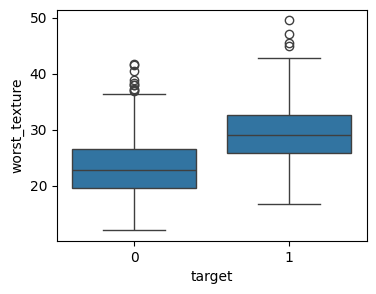

In [6]:
plt.figure(figsize=(4, 3))
sns.boxplot(data=df, x='target', y='worst_texture');

### <font color = " red">worst_area

<font color = " red">Embora a classe negativa quase não encoste no q2 da classe positiva, q1 da classe positiva avança bastante na classe negativa. por outro lado, as medianas e os quartis 2 e 3 de ambas as classes esão bem separados, fazendo desta outra variável promissora na divisão das classes alvo.

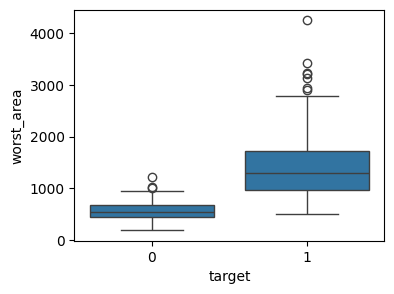

In [7]:
plt.figure(figsize=(4, 3))
sns.boxplot(data=df, x='target', y='worst_area');

###<font color = " red">Análise dos pairplots
<font color = " red">Conforme os bloxplots previam, *mean_fractal_dimension* e *worst_texture* são variaveis ruins para uma analise. Como o pairplot pode exibir, as amostras são dispersas e sem correlaçao com as demais variáveis. Por outro lado, *mean_perimeter*, *worst_perimeter* e *worst_area* mostram-se redundantes devido a alta correlação do trio. O mais indicado é que apenas uma destas preditoras continuem compondo a análise.

<font color = " red">Em última análise, julgo como a variável mais relevente a *mean_concave_points*, pois mostra uma média correlação no pairplot e as classes 0 e 1 são bem divididas quando vistas no bloxplot.

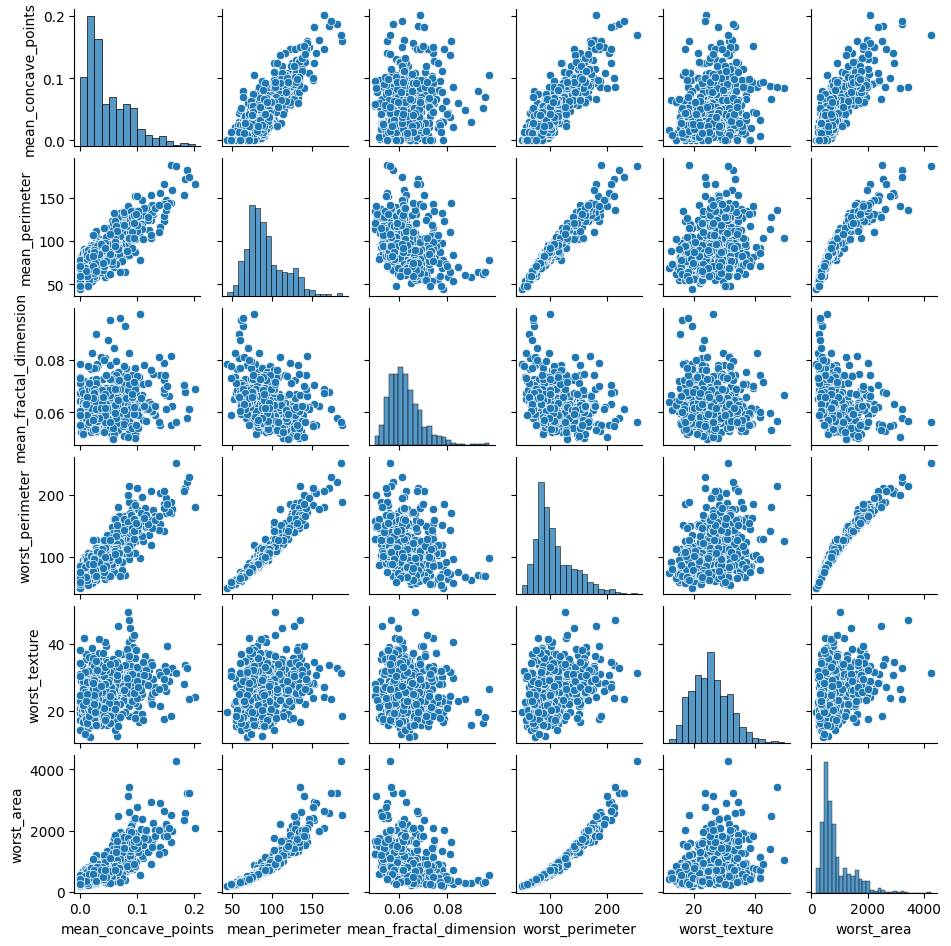

In [8]:
sns.pairplot(df.drop('target', axis=1), height=1.6, aspect=1);

## 2. Modelos de regressão linear ajustado pelo pesquisador
(alguns códigos são sugeridos)


### <font color = " red">Análise do modelo de regressão.

<font color = " red">Verificando a coluna P>|t| os valores relevantes são os que possuem zero como resultado, pois os demais superam bem a margem de 5%. </br>
Apesar de *target* aparecer como uma preditora relevante, ela deveria ser descartada já que é o alvo da análise, mas por outro lado, é possivel que ela tenha aparecido entre as relevantes por uma possivel correlação com a variável *worst_texture* que aqui erroneamente foi colocada como a target do modelo, então acredito que caso o modelo estivesse corretamente parametrizado, *worst_texture* também seria relevante em função de *target* ser relevante neste modelo errado.

In [9]:
# Modelo linear ajustado pelo pesquisador

from statsmodels.formula.api import ols

mod = ols('worst_texture ~  mean_concave_points + mean_perimeter + mean_fractal_dimension + worst_perimeter + worst_area + target', data=df)
res = mod.fit()
print(res.summary())


                            OLS Regression Results                            
Dep. Variable:          worst_texture   R-squared:                       0.254
Model:                            OLS   Adj. R-squared:                  0.246
Method:                 Least Squares   F-statistic:                     31.88
Date:                Sun, 15 Jun 2025   Prob (F-statistic):           4.67e-33
Time:                        01:55:15   Log-Likelihood:                -1756.7
No. Observations:                 569   AIC:                             3527.
Df Residuals:                     562   BIC:                             3558.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 25

## 3. Modelo de regressão logística

### <font color = " red">Analise das influências das preditoras *mean_perimeter* e *worst_texture* na presença de tumor.

<font color = " red">A razão de chances (OR) para *mean_perimeter* é de 0,63 o que significa que a cada ponto que *mean_perimeter* sobe, a chance de haver tumor decai 38% (1 - OR de mean_perimeter).<br>
No caso da variavel *worst_texture* a cada ponto que esta variavel sobe, a chance de haver tumor aumenta em 34%.

In [10]:
# Atribui as preditoras, excluindo a coluna target
preditoras = df.drop('target', axis=1)

# Atribui a resposta
resposta = df['target']

In [11]:
# Ajuste do modelo de regressão logística
glm_binom = sm.GLM(resposta, preditoras, family=sm.families.Binomial())
res = glm_binom.fit()
print(res.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 target   No. Observations:                  569
Model:                            GLM   Df Residuals:                      563
Model Family:                Binomial   Df Model:                            5
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -40.224
Date:                Sun, 15 Jun 2025   Deviance:                       80.447
Time:                        01:55:15   Pearson chi2:                 4.88e+03
No. Iterations:                    10   Pseudo R-squ. (CS):             0.6925
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
mean_concave_points      162

In [12]:
#fórmula para OR = exp(bj)
OR_mean_perimeter = np.exp(-0.4594) # beta obtido da coluna "coef"
OR_worst_texture = np.exp(0.2926) # beta obtido da coluna "coef"

print(f"OR para mean_perimeter {round(OR_mean_perimeter, 3)}")
print(f"OR para worst_texture {round(OR_worst_texture, 3)}")

OR para mean_perimeter 0.632
OR para worst_texture 1.34


### <font color = " red"> Analise dos resíduos

<font color = " red">
Desenvolva uma análise de resíduos e, caso haja observações em destaque, identifique-as e descreva as suas características.

</br>
<font color = " red">



<font color = "red">O gráfico mostra um bom ajuste, com os residuos bem próximos de zero. Por outro lado, também há resíduos com uma distância relevante, tanto no lado positivo como negativo. Estes pontos distantes indicam os casos em que o modelo indentificou erroneamente as categorias dem que o tumor é maligno ou não, sendo que nos erros negativos o modelo indentificou falsos casos de tumor maligno e nos casos de erros positivos foram constatados falsos casos de tumores benignos.</br></br>
Os pontos mais distantes de zero (outliers) indicam as situações em que o modelo desempenhou o seu papel de forma pior e que precisam de atenção especial, pois é necessário identificar se as variaveis precisam de transformação, ou se o modelo precisa ser ajustado ou até mesmo se é necessária a adição de novas variáveis.

In [13]:
import plotly.graph_objects as go

# Resíduo componente do desvio
resid_dev = res.resid_deviance

fig = go.Figure()

fig.add_trace(go.Scatter(
    y=resid_dev,
    mode='markers',
    marker=dict(size=6, color='royalblue', opacity=0.7),
    name='Resíduo do Desvio'
))

fig.update_layout(
    title="Resíduos do Desvio (Deviance Residuals)",
    xaxis_title="Índice da Observação",
    yaxis_title="Resíduo do Desvio",
    template="plotly_white"
)

fig.show()


### <font color = " red"> Porquê usar a regressão logistica neste caso?

<font color = " red">A regressão logistica se faz necessária devido a sua caracteristica receber um conjunto de preditores numéricos e ter como saída a probabilidade de um evento binário acontecer, baseado em um limiar definido pelo valor p. Este modelo é adequado para casos de classificação de presença de doenças, como este dado na avaliação.